### Conformer-Transducer

This notebook shows the entire process from loading data to training. Comments and key points are written in each section. Some code could be optimized, but we only modified the comments in order to be able to reproduce the results.

### Initialize

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import math
import pickle
from scipy.signal import stft
from typing import List, Tuple
from torchaudio.transforms import RNNTLoss
import matplotlib.pyplot as plt
import numpy as _np
from torch.utils.data import Subset
from IPython.display import clear_output, display, update_display
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEBUG = False

In [ ]:
feature_dim = (0, 512)
# clamp = (-2, 4)    # if you want to truncate the extreme values
sample_idx = 0       # which sample to check after training

# STFT parameters, should not affect anything in this notebook
fs = 50  
nperseg = 64  
noverlap = 60  

stack_layers = 17    # how many frequency layers to use
batch_size = 1       # batch size

data_root = '/kaggle/input/processed-hdf5-32-28-all-layers/processed_hdf5_32_28_all_layers'     # modify as needed

In [ ]:
# This cell contains classes for data augmentation.
# We only attempted conservative approaches such as gain and Gaussian noise; 
# other data augmentation methods require further experimentation.

import random

# ====== input size should be (C, F, T) ======
class ComposeAug:
    def __init__(self, ops): self.ops = ops
    def __call__(self, x):
        for op in self.ops: x = op(x)
        return x

class RandomGaussianNoise:
    def __init__(self, p=0.8, std=0.01): self.p, self.std = p, std
    def __call__(self, x):
        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.std
        return x

class RandomGain:
    def __init__(self, p=0.5, min_gain=0.97, max_gain=1.03):
        self.p, self.min_gain, self.max_gain = p, min_gain, max_gain
    def __call__(self, x):
        if random.random() < self.p:
            g = random.uniform(self.min_gain, self.max_gain)
            x = x * g
        return x

class RandomTimeMask:
    def __init__(self, p=0.5, max_width=8, num_masks=1, value=0.0):
        self.p, self.max_width, self.num_masks, self.value = p, max_width, num_masks, value
    def __call__(self, x):  
        if random.random() < self.p:
            C, F_, T = x.shape
            for _ in range(self.num_masks):
                w = random.randint(1, min(self.max_width, max(1, T//10)))
                t0 = random.randint(0, max(0, T - w))
                x[..., t0:t0+w] = self.value
        return x

class RandomFreqMask:
    def __init__(self, p=0.5, max_width=12, num_masks=1, value=0.0):
        self.p, self.max_width, self.num_masks, self.value = p, max_width, num_masks, value
    def __call__(self, x):
        if random.random() < self.p:
            C, F_, T = x.shape
            for _ in range(self.num_masks):
                w = random.randint(1, min(self.max_width, max(1, F_//10)))
                f0 = random.randint(0, max(0, F_ - w))
                x[:, f0:f0+w, :] = self.value
        return x

class RandomTimeStretch:
    """
    Time stretching (simulates faster/slower speech)
    - preserve_len=True: after compression/expansion, crop or pad back to the original T to avoid changing sequence length (most stable for CTC/RNNT)
    - preserve_len=False: directly return the changed T (more realistic, but ensure T' is not too short)
    """
    def __init__(self, p=0.8, min_scale=0.85, max_scale=1.15, preserve_len=True, mode='linear'):
        self.p, self.min_scale, self.max_scale = p, min_scale, max_scale
        self.preserve_len, self.mode = preserve_len, mode

    def __call__(self, x):  
        if random.random() >= self.p: return x
        C, F_, T = x.shape
        scale = random.uniform(self.min_scale, self.max_scale)
        target_T = max(1, int(round(T * scale)))

        # 1D interpolation along the time axis for stretching: reshape -> (1, C*F, T)
        x1 = x.contiguous().view(1, C * F_, T)
        x1 = F.interpolate(x1, size=target_T, mode='linear' if self.mode=='linear' else 'nearest', align_corners=False if self.mode=='linear' else None)
        x1 = x1.view(C, F_, target_T)

        if self.preserve_len:
            # to original T：pad or center-crop
            if target_T < T:
                pad_total = T - target_T
                pad_left = pad_total // 2
                pad_right = pad_total - pad_left
                x1 = F.pad(x1, (pad_left, pad_right), mode='replicate') 
            elif target_T > T:
                start = (target_T - T) // 2
                x1 = x1[:, :, start:start+T]
            # length is kept as T
            return x1
        else:
            return x1


# seed_worker for DataLoader (ensure different random seeds across workers)
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# augmentation pipeline
train_augment = ComposeAug([
    # RandomTimeStretch(p=0.8, min_scale=0.9, max_scale=1.1, preserve_len=True),
    RandomGaussianNoise(p=0.8, std=0.01),
    RandomGain(p=0.5, min_gain=0.97, max_gain=1.03),
    # RandomTimeMask(p=0.4, max_width=8, num_masks=1, value=0.0),
    # RandomFreqMask(p=0.4, max_width=12, num_masks=1, value=0.0),
])


In [ ]:
def rnn_decode(model, dataset, data_idx, max_symbols_per_step=10):
    model.eval()
    x = dataset[data_idx][0].unsqueeze(0).to(DEVICE)   # 固定样本
    feat_lens = torch.tensor([x.shape[-1]]).to(DEVICE)

    with torch.no_grad():
        hyps = model.greedy_decode(x, feat_lens, max_symbols_per_step=max_symbols_per_step)[0].tolist()
    return hyps

In [ ]:
# function for calculating the output shape after convolutional layer
# output shape determin the size of subsequent layers
def calculate_conv_output_shape(input_dim, kernel_size, stride, padding, dilation=1, return_rf=False):
    """
    Calculate the output length of a convolution along the width/frequency dimension,
    and optionally return the single-layer receptive field and jump (effective stride).

    Parameters:
        input_dim (int): Input width (e.g., frequency bins)
        kernel_size (int or tuple): Convolution kernel (K_h, K_w) or a single value
        stride (int or tuple): Stride (S_h, S_w) or a single value
        padding (int or tuple): Padding (P_h, P_w) or a single value
        dilation (int or tuple): Dilation (D_h, D_w) or a single value
        return_rf (bool): If True, return (W_out, rf, jump); otherwise return only W_out (for compatibility)

    Returns:
        int or (int, int, int)
    """

    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(padding, int):
        padding = (padding, padding)
    if isinstance(dilation, int):
        dilation = (dilation, dilation)

    W_in = int(input_dim)
    K_h, K_w = kernel_size
    S_h, S_w = stride
    P_h, P_w = padding
    D_h, D_w = dilation

    # Use the standard conv output formula including dilation
    W_out = (W_in + 2 * P_w - D_w * (K_w - 1) - 1) // S_w + 1

    # Single-layer receptive field (width direction) and jump (effective stride)
    rf = D_w * (K_w - 1) + 1
    jump = S_w

    if return_rf:
        return int(W_out), int(rf), int(jump)
    return int(W_out)

In [ ]:
# function for calculating valid lengths (used for masking if needed) after multiple convolutional layers
def conv_valid_length_multi(
    lengths: List[int],
    layers: List[Tuple[Tuple[int, ...], Tuple[int, ...], Tuple[int, ...], Tuple[int, ...]]]
) -> List[int]:
    """
    Compute the valid lengths of a batch of sequences after multiple convolutional layers
    (considering only the time/sequence dimension).

    Parameters:
        lengths: the true valid length of each item in the batch (pre-padding).
        layers: list of convolution layer parameter tuples:
            Format: [
                (kernel_size, stride, padding, dilation),
                ...
            ]
            Note: these parameters must be tuples, e.g. for 1D use kernel_size=(3,), stride=(2,), padding=(1,), dilation=(1,)

    Returns:
        A list of lengths for each item after applying all convolution layers.
    """

    out_lengths = lengths[:]
    for (kernel_size, stride, padding, dilation) in layers:
        new_lengths = []
        for L in out_lengths:
            # Only calculate the first dimension (assumed to be the time/sequence dimension)
            k, s, p, d = kernel_size[0], stride[0], padding[0], dilation[0]
            L_out = math.floor((L + 2*p - d*(k - 1) - 1) / s) + 1
            new_lengths.append(max(L_out, 0))
        out_lengths = new_lengths
    return out_lengths

# example usage
lengths = torch.tensor([160,150])  # input lengths of each item in the batch

layers = [
    [(3,1), (2,1), (1,0), (1,1)],  # Conv1: kernel=3, stride=2, padding=1, dilation=1
    [(3,1), (2,1), (1,0), (1,1)],  # Conv2: kernel=3, stride=2, padding=1, dilation=1
]

print(conv_valid_length_multi(lengths, layers))

[40, 38]


In [ ]:
# convert lengths to padding mask
def lengths_to_padding_mask(lengths, max_len=None):
    # lengths: 1D tensor/list, values are valid time steps for each sample
    if not isinstance(lengths, torch.Tensor):
        lengths = torch.as_tensor(lengths, dtype=torch.long)
    if max_len is None:
        max_len = int(lengths.max().item())
    idx = torch.arange(max_len, device=lengths.device).unsqueeze(0)  # (1, T)
    return idx >= lengths.unsqueeze(1)      # (B, T), True for padding

In [ ]:
# this cell is copied from the Github of the competition

import numpy as np
import re
from g2p_en import G2p

LOGIT_PHONE_DEF = [
    'BLANK', 'SIL', # blank and silence
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH'
]
SIL_DEF = ['SIL']


# remove puntuation from text
def remove_punctuation(sentence):
    # Remove punctuation
    sentence = re.sub(r'[^a-zA-Z\- \']', '', sentence)
    sentence = sentence.replace('--', '').lower()
    sentence = sentence.replace(" '", "'").lower()

    sentence = sentence.strip()
    sentence = ' '.join(sentence.split())

    return sentence


# Convert RNN logits to argmax phonemes
def logits_to_phonemes(logits):
    seq = np.argmax(logits, axis=1)
    seq2 = np.array([seq[0]] + [seq[i] for i in range(1, len(seq)) if seq[i] != seq[i-1]])

    phones = []
    for i in range(len(seq2)):
        phones.append(LOGIT_PHONE_DEF[seq2[i]])

    # Remove blank and repeated phonemes
    phones = [p for p in phones if  p!='BLANK']
    phones = [phones[0]] + [phones[i] for i in range(1, len(phones)) if phones[i] != phones[i-1]]

    return phones


# Convert text to phonemes
def sentence_to_phonemes(thisTranscription, g2p_instance=None):
    if not g2p_instance:
        g2p_instance = G2p()

    # Remove punctuation
    thisTranscription = remove_punctuation(thisTranscription)

    # Convert to phonemes
    phonemes = []
    if len(thisTranscription) == 0:
        phonemes = SIL_DEF
    else:
        for p in g2p_instance(thisTranscription):
            if p==' ':
                phonemes.append('SIL')

            p = re.sub(r'[0-9]', '', p)  # Remove stress
            if re.match(r'[A-Z]+', p):  # Only keep phonemes
                phonemes.append(p)

        #add one SIL symbol at the end so there's one at the end of each word
        phonemes.append('SIL')
    
    return phonemes, thisTranscription


# Calculate WER or PER
def calculate_error_rate(r, h):
    """
    Calculation of WER or PER with Levenshtein distance.
    Works only for iterables up to 254 elements (uint8).
    O(nm) time ans space complexity.
    ----------
    Parameters:
    r : list of true words or phonemes
    h : list of predicted words or phonemes
    ----------
    Returns:
    Word error rate (WER) or phoneme error rate (PER) [int]
    ----------
    Examples:
    >>> calculate_wer("who is there".split(), "is there".split())
    1
    >>> calculate_wer("who is there".split(), "".split())
    3
    >>> calculate_wer("".split(), "who is there".split())
    3
    """
    # initialization
    d = np.zeros((len(r)+1)*(len(h)+1), dtype=np.uint32)
    d = d.reshape((len(r)+1, len(h)+1))
    for i in range(len(r)+1):
        for j in range(len(h)+1):
            if i == 0:
                d[0][j] = j
            elif j == 0:
                d[i][0] = i

    # computation
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                substitution = d[i-1][j-1] + 1
                insertion    = d[i][j-1] + 1
                deletion     = d[i-1][j] + 1
                d[i][j] = min(substitution, insertion, deletion)

    return d[len(r)][len(h)]


# calculate aggregate WER or PER
def calculate_aggregate_error_rate(r, h):

    # list setup
    err_count = []
    item_count = []
    error_rate_ind = []

    # calculate individual error rates
    for x in range(len(h)):
        r_x = r[x]
        h_x = h[x]

        n_err = calculate_error_rate(r_x, h_x)

        item_count.append(len(r_x))
        err_count.append(n_err)
        error_rate_ind.append(n_err / len(r_x))

    # Calculate aggregate error rate
    error_rate_agg = np.sum(err_count) / np.sum(item_count)

    # calculate 95% CI
    item_count = np.array(item_count)
    err_count = np.array(err_count)
    nResamples = 10000
    resampled_error_rate = np.zeros([nResamples,])
    for n in range(nResamples):
        resampleIdx = np.random.randint(0, item_count.shape[0], [item_count.shape[0]])
        resampled_error_rate[n] = np.sum(err_count[resampleIdx]) / np.sum(item_count[resampleIdx])
    error_rate_agg_CI = np.percentile(resampled_error_rate, [2.5, 97.5])

    # return everything as a tuple
    return (error_rate_agg, error_rate_agg_CI[0], error_rate_agg_CI[1], error_rate_ind)

### Load Data

In [ ]:
class ProcessedH5Dataset(Dataset):
    def __init__(self, processed_files, augment=None, is_train=False):
        self.files = processed_files
        self.index = []
        self.augment = augment
        self.is_train = is_train
        self._fh_cache = {}  # per-worker file handle cache
        
        # a mapping from dataset index to (file_idx, sample_key, n_time_steps)
        for file_idx, file_path in enumerate(processed_files):
            with h5py.File(file_path, 'r') as f:
                for sample_idx, key in enumerate(f.keys()):
                    g = f[key]
                    n_time_steps = g.attrs.get("n_time_steps", 0)  # get sequence length
                    self.index.append((file_idx, key, n_time_steps))

    def __len__(self):
        return len(self.index)

    def _open(self, file_idx):    # open HDF5 file with caching
        if file_idx not in self._fh_cache or not self._fh_cache[file_idx]:
            self._fh_cache[file_idx] = h5py.File(self.files[file_idx], 'r', libver='latest', swmr=True)
        return self._fh_cache[file_idx]

    def __getitem__(self, idx):
        fi, key, _ = self.index[idx]
        f = self._open(fi)
        g = f[key]
        time_freq_features = torch.tensor(g["time_freq_features"][:][0:stack_layers, feature_dim[0]:feature_dim[1],:]) 
        n_time_steps = torch.tensor(g.attrs["n_time_steps"])
        seq_class_ids = torch.tensor(g["seq_class_ids"][:])
        seq_len = torch.tensor(g.attrs["seq_len"])

        if self.is_train and self.augment is not None:
            time_freq_features = self.augment(time_freq_features)
        
        return time_freq_features, n_time_steps, seq_class_ids[:seq_len], seq_len, idx

In [ ]:
# show a sample data
sample_path = os.path.join(data_root, 't15.2023.08.11/data_train_processed.hdf5')
with h5py.File(sample_path, "r") as f:
    g = f['trial_0001']
    feats = g["time_freq_features"]  
    print(feats.shape)
    print(g['input_features'][:].shape)
    print(g["seq_class_ids"][:g.attrs["seq_len"]].shape)
    print(g.attrs["seq_len"])
    print(g.attrs['sentence_label'])
    print(g.attrs['n_time_steps'])

(17, 512, 122)
(481, 512)
(19,)
19
My family is closer.
481


In [16]:
# training set
root = data_root
processed_files = []
for sess in os.listdir(root):
    # print(sess)
    fp = os.path.join(root, sess, "data_train_processed.hdf5")
    if os.path.exists(fp):
        processed_files.append(fp)
    
print('processed_training_files:', len(processed_files))
training_dataset =  ProcessedH5Dataset(processed_files, augment=train_augment, is_train=True)

processed_training_files: 45


In [17]:
# val set
root = data_root
processed_files = []
for sess in os.listdir(root):
    # print(sess)
    fp = os.path.join(root, sess, "data_val_processed.hdf5")
    if os.path.exists(fp):
        processed_files.append(fp)
    
print('processed_val_files:', len(processed_files))
val_dataset =  ProcessedH5Dataset(processed_files, augment=None, is_train=False)

processed_val_files: 41


In [ ]:
# test set
root = data_root
processed_files = []
for sess in os.listdir(root):
    # print(sess)
    fp = os.path.join(root, sess, "data_test_processed.hdf5")
    if os.path.exists(fp):
        processed_files.append(fp)
    
print('processed_test_files:', len(processed_files))
test_dataset =  ProcessedH5Dataset(processed_files)

In [ ]:
# collate_fn for DataLoader. Containing padding logic for variable-length sequences.
# In implementation, we set batch_size=1 to avoid any padding issues and losses being averaged over samples.

def collate_fn(batch):    
    encoder_inputs, input_len, decoder_inputs, target_len, idx = zip(*batch)  # encoder_inputs is a tensors list of (C, F, T)
    print(len(encoder_inputs), encoder_inputs[0].shape) if DEBUG else None

    # list of input lengths to return. The unpacked input_len above is an attribute of the original dataset, 
    # but the data used for training has been preprocessed.
    input_len = [int(x.shape[2]) for x in encoder_inputs]

    # permute and view encoder_inputs as (T, D) for pad_sequence to pad along time dimension
    enc_list = [x.permute(2, 0, 1).contiguous().view(x.shape[2], -1) for x in encoder_inputs]  # list of (T, C*F)

    # padding on time dimension -> (B, T_max, D)
    padded_time_feat = torch.nn.utils.rnn.pad_sequence(enc_list, batch_first=True, padding_value=0.0)

    # recover to (B, C, F, T)
    B, T_max, D = padded_time_feat.shape
    print(T_max) if DEBUG else None
    C, F = encoder_inputs[0].shape[0], encoder_inputs[0].shape[1]
    padded_encoder_inputs = padded_time_feat.view(B, T_max, C, F).permute(0, 2, 3, 1).contiguous()  # (B, C, F, T)

    # pad decoder_inputs, eg. phoneme sequences
    padded_decoder_inputs = torch.nn.utils.rnn.pad_sequence(decoder_inputs, batch_first=True, padding_value=0)

    return padded_encoder_inputs, torch.tensor(input_len), padded_decoder_inputs, torch.tensor(target_len), idx

# create DataLoader
num_workers = 0
training_dataloader = DataLoader(
    training_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn,
    num_workers=num_workers, pin_memory=False, persistent_workers=False,
    worker_init_fn=seed_worker
)
val_dataloader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn,
    num_workers=num_workers, pin_memory=False, persistent_workers=False,
    worker_init_fn=seed_worker
)

# show a batch
batch = next(iter(training_dataloader))
padded_encoder_inputs, input_len, padded_decoder_inputs, target_len, idx = batch
print(padded_encoder_inputs.shape, padded_decoder_inputs.shape, idx)
# print(padded_encoder_inputs[1])
print(input_len)

torch.Size([1, 17, 512, 417]) torch.Size([1, 26]) (5295,)
tensor([417])


In [ ]:
# subset of val dataset for quick validation
def make_val_subset_loader(dataset, sample_size=16, batch_size=None, seed=None):
    """
    Randomly sample `sample_size` examples from `dataset` each call and return a DataLoader
    (do not shuffle the order within the subset).
    `seed`: None means different samples each time; providing an int makes sampling reproducible.
    """
    n = len(dataset)
    if sample_size >= n:
        chosen = list(range(n))
    else:
        rng = np.random.RandomState(seed) if seed is not None else np.random
        chosen = rng.choice(n, size=sample_size, replace=False).tolist()
    subset = Subset(dataset, chosen)
    if batch_size is None:
        batch_size = sample_size
    return DataLoader(subset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

### Model

#### Conformer

1.Fine tuning kernel_size, stride and other parameters of each conv layer have impact on performance, but is not deterministic;  
2.Adding Transducer on Conformer brings qualitative change;  
3.Inputs are encoded as (B, T_, 256) after Conv2dSubsampling. Increasing 256 to a lager value (eg. 512) may help, but requires more GPU memory.

In [ ]:
# ----------- Positional Encoding -----------

class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=10000):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, dim, 2).float() * -(math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)   
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, dim)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ----------- FeedForward -----------
class FeedForward(nn.Module):
    def __init__(self, dim, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * expansion),   
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * expansion, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# ----------- Convolution Module -----------
class ConvolutionModule(nn.Module):
    def __init__(self, dim, expansion_factor=2, kernel_size=31, dropout=0.1):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.pointwise_conv1 = nn.Conv1d(dim, dim * expansion_factor * 2, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        self.depthwise_conv = nn.Conv1d(dim * expansion_factor, dim * expansion_factor,
                                        kernel_size=kernel_size, padding=kernel_size // 2,
                                        groups=dim * expansion_factor)
        # self.batchnorm = nn.BatchNorm1d(dim * expansion_factor)
        self.swish = nn.SiLU()
        self.pointwise_conv2 = nn.Conv1d(dim * expansion_factor, dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask: torch.Tensor | None = None):  # pad_mask: (B, T), True=padding
        # x: (B, T, D)
        x = self.ln(x)
        x = x.transpose(1, 2)  # (B, D, T)
        x = self.pointwise_conv1(x)
        x = self.glu(x)
        x = self.depthwise_conv(x)
        # x = self.batchnorm(x)
        x = self.swish(x)
        x = self.pointwise_conv2(x)
        x = x.transpose(1, 2)  # (B, T, D)
        x = self.dropout(x)
        if pad_mask is not None:
            x = x.masked_fill(pad_mask.unsqueeze(-1), 0.0)
        return x

# ----------- Conformer Block -----------
class ConformerBlock(nn.Module):
    def __init__(self, dim, heads=8, ff_expansion=4, conv_expansion=2,   
                 conv_kernel_size=31, dropout=0.1):   
        super().__init__()
        self.ffn1 = FeedForward(dim, ff_expansion, dropout)
        self.ffn2 = FeedForward(dim, ff_expansion, dropout)

        self.ln_attn = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.dropout_attn = nn.Dropout(dropout)

        self.conv = ConvolutionModule(dim, conv_expansion, conv_kernel_size, dropout)

        self.ln_out = nn.LayerNorm(dim)

    def forward(self, x, mask=None):        # (B, T_, D), mask: (B, T_) True=padding
        x = x + 0.5 * self.ffn1(x)
        if mask is not None:
            x = x.masked_fill(mask.unsqueeze(-1), 0.0)

        x_norm = self.ln_attn(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, key_padding_mask=mask, need_weights=False)
        x = x + self.dropout_attn(attn_out)
        if mask is not None:
            x = x.masked_fill(mask.unsqueeze(-1), 0.0)

        x = x + self.conv(x, pad_mask=mask)
        if mask is not None:
            x = x.masked_fill(mask.unsqueeze(-1), 0.0)

        x = x + 0.5 * self.ffn2(x)
        if mask is not None:
            x = x.masked_fill(mask.unsqueeze(-1), 0.0)

        return self.ln_out(x)

# ----------- Conformer Encoder -----------
class ConformerEncoder(nn.Module):
    def __init__(self, dim, depth=6, heads=8, ff_expansion=4,       
                 conv_expansion=2, conv_kernel_size=31,
                 dropout=0.1, use_positional_encoding=True):
        super().__init__()
        self.use_pe = use_positional_encoding
        if self.use_pe:
            self.pos_encoding = PositionalEncoding(dim)

        self.layers = nn.ModuleList([
            ConformerBlock(dim, heads, ff_expansion, conv_expansion,
                           conv_kernel_size, dropout)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)

    def forward(self, x, mask=None):           # (B, T_, D) 
        if self.use_pe:
            x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, mask)

        return self.norm(x)


# ----------- Conv2D Subsampling Frontend -----------
class Conv2dSubsampling(nn.Module):

    DEFAULT_CONV_KWARGS = {
        "kernel_size": (3, 3),
        "stride": (1, 1),   # no stride is better than stride 2 for time dimension
        "padding": (1, 1),  # we do not need stride for subsampling as the input is already 'downsampled' in preprocessing
        "dilation": (1, 1)
    }

    DEFAULT_CONV_KWARGS_2 = {
        "kernel_size": (7, 7),   # kernel_size might be a optimizable hyperparameter as it determines how inputs will be encoded before being input to ConformerEncoder
        "stride": (1, 1),  
        "padding": (3, 3),
        "dilation": (1, 1)
    }


    def __init__(self, in_dim, out_dim):   # (B, C, T, F), say, (4, 17, 322, 512). in_dim refers to C, 17
        super().__init__()
        self.conv = nn.Sequential(      
            nn.Conv2d(in_dim, out_dim, **self.DEFAULT_CONV_KWARGS),  # (B, C, T, F) -> (B, D, T_, F_)
            nn.ReLU(),
            nn.Conv2d(out_dim, out_dim, **self.DEFAULT_CONV_KWARGS_2),  # -> (B, D, T_, F_)
            nn.ReLU(),
        )
        conv1_shape = calculate_conv_output_shape(feature_dim[1]-feature_dim[0], **self.DEFAULT_CONV_KWARGS)
        conv2_shape = calculate_conv_output_shape(conv1_shape, **self.DEFAULT_CONV_KWARGS_2)
        self.linear = nn.Linear(out_dim * conv2_shape, out_dim)  

    def forward(self, x, feat_lens):     # x: (B, C, F, T), feat_lens: (B,)   
        print(x.shape) if DEBUG==True else None
        x = x.transpose(2, 3)  # (B, C, F, T) -> (B, C, T, F)
        x = x.contiguous(memory_format=torch.channels_last)
        x = self.conv(x)    # (B, D, T_, F_)
        
        b, d, t, f = x.size()    
        x = x.transpose(1, 2).contiguous().view(b, t, d * f) 

        # calculate valid lengths T_ after conv layers
        layers = [
            list(self.DEFAULT_CONV_KWARGS.values()),
            list(self.DEFAULT_CONV_KWARGS_2.values()),
        ]
        base_lens = feat_lens.tolist() if isinstance(feat_lens, torch.Tensor) else feat_lens
        x_lens = conv_valid_length_multi(base_lens, layers)
        x_lens = torch.as_tensor(x_lens, device=x.device, dtype=torch.long)

        # check length validity
        if (x_lens > t).any() or (x_lens <= 0).any():  
            if DEBUG:
                print(f"[WARN] subsampling length mismatch: {x_lens.tolist()} vs T_={t}")
        x_lens = x_lens.clamp(min=1, max=t)

        y = self.linear(x)  # (B, T_, D)
        # zero out padding time steps to prevent bias from leaking non-zero values
        # there should be no padding time steps in practice as we use batch_size=1
        pad_mask = lengths_to_padding_mask(x_lens, max_len=t).to(y.device)  # (B, T_)
        y = y.masked_fill(pad_mask.unsqueeze(-1), 0.0)   
        return y, x_lens  # (B, T_, D), (B,)


# ----------- Conformer-CTC Model -----------
class ConformerCTC(nn.Module):
    def __init__(self, input_dim, num_classes, encoder_dim, num_layers=6):
        super().__init__()
        self.subsampling = Conv2dSubsampling(input_dim, encoder_dim)
        self.encoder = ConformerEncoder(dim=encoder_dim, depth=num_layers, heads=4)  
        self.ctc_head = nn.Linear(encoder_dim, num_classes)

    def forward(self, x, feat_lens):
        x, x_lens = self.subsampling(x, feat_lens)  # x: (B, T_, D), x_lens: (B,)
        key_padding_mask = lengths_to_padding_mask(x_lens, max_len=x.size(1)).to(x.device)  # (B, T_)
        out = self.encoder(x, mask=key_padding_mask)    # (B, T_, D)
        logits = self.ctc_head(out)  # (B, T_, C)
        return logits, x_lens


# test the ConformerCTC model with dummy data
if __name__ == "__main__":
    num_classes = 41  
    feats = padded_encoder_inputs.to(DEVICE)
    print('feat:', feats.shape) if DEBUG==True else None
    feat_lens = input_len 
    model = ConformerCTC(input_dim=stack_layers, encoder_dim=256, num_classes=num_classes).to(DEVICE)
    logits, out_lens = model(feats, feat_lens)

#### Transducer

1.In decoding, beam search does not perform as well as greedy.

In [ ]:
# ----------- Predictor (language prior based on previously emitted labels) -----------
class RNNTPredictor(nn.Module):
    def __init__(self, vocab_size: int, pred_dim: int, num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, pred_dim)   
        self.rnn = nn.GRU(pred_dim, pred_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, y_in: torch.Tensor, y_in_len: torch.Tensor):
        # y_in: (B, U+1), the first position should be blank as the start; y_in_len: (B,) = target_len + 1
        e = self.embed(y_in)                       # (B, U+1, Dp)
        e = self.dropout(e)
        g, _ = self.rnn(e)                         # (B, U+1, Dp)
        return g


# ----------- Joint (fusion of encoder and predictor) -----------
class RNNTJoint(nn.Module):
    def __init__(self, enc_dim: int, pred_dim: int, joint_dim: int, vocab_size: int, dropout: float = 0.1):
        super().__init__()
        self.enc_proj = nn.Linear(enc_dim, joint_dim)
        self.pred_proj = nn.Linear(pred_dim, joint_dim)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(joint_dim, vocab_size)  # project to vocab size

    def forward(self, h: torch.Tensor, g: torch.Tensor):
        # h: (B, T, De) from encoder; g: (B, U+1, Dp) from predictor
        # compute outer sum, we have (B, T, U+1, joint_dim)
        h_ = self.enc_proj(h).unsqueeze(2)           # (B, T, 1, J)
        g_ = self.pred_proj(g).unsqueeze(1)          # (B, 1, U+1, J)
        z = self.act(h_ + g_)                        # broadcast add
        z = self.dropout(z)
        logits = self.out(z)                         # (B, T, U+1, V)
        return logits


# ----------- Conformer-Transducer -----------
class ConformerTransducer(nn.Module):
    def __init__(self,
                 input_dim: int,          # input channels for Conv2dSubsampling frontend (stack_layers)
                 num_classes: int,        # including blank (recommended blank_id=0)
                 encoder_dim: int = 256,
                 num_layers: int = 8,
                 encoder_heads: int = 4,
                 ff_expansion: int = 2,
                 conv_expansion: int = 2,
                 conv_kernel_size: int = 31,
                 kernel_size: int = 31,
                 dropout: float = 0.2,
                 pred_dim: int = 256,
                 pred_layers: int = 1,
                 joint_dim: int = 320,
                 blank_id: int = 0):
        super().__init__()
        self.blank_id = blank_id
        self.subsampling = Conv2dSubsampling(input_dim, encoder_dim)
        self.encoder = ConformerEncoder(
            dim=encoder_dim, depth=num_layers, heads=encoder_heads,
            ff_expansion=ff_expansion, conv_expansion=conv_expansion,
            conv_kernel_size=conv_kernel_size, dropout=dropout
        )
        self.predictor = RNNTPredictor(vocab_size=num_classes, pred_dim=pred_dim, num_layers=pred_layers, dropout=dropout)
        self.joint = RNNTJoint(enc_dim=encoder_dim, pred_dim=pred_dim, joint_dim=joint_dim, vocab_size=num_classes, dropout=dropout)
        # CTC head
        self.ctc_head = nn.Linear(encoder_dim, num_classes)

    def forward(self, x, feat_lens, targets=None, target_lens=None):
        enc, enc_lens = self.subsampling(x, feat_lens)              # (B, T_, De), (B,)
        key_padding_mask = lengths_to_padding_mask(enc_lens, max_len=enc.size(1)).to(enc.device)  # (B, T_)
        enc = self.encoder(enc, mask=key_padding_mask)              # (B, T_, De)
        enc = enc.masked_fill(key_padding_mask.unsqueeze(-1), 0.0)

        if targets is None:
            return enc, enc_lens

        # CTC logits
        ctc_logits = self.ctc_head(enc)                             # (B, T_, V)
        ctc_logits = ctc_logits.masked_fill(key_padding_mask.unsqueeze(-1), 0.0)

        # Transducer logits
        B = targets.size(0)
        y_in = torch.full((B, targets.size(1) + 1), self.blank_id, dtype=targets.dtype, device=targets.device)
        y_in[:, 1:] = targets                                         # (B, U+1)
        y_in_lens = target_lens + 1

        pred = self.predictor(y_in, y_in_lens)                        # (B, U+1, Dp)
        u_pad_mask = lengths_to_padding_mask(y_in_lens, max_len=pred.size(1)).to(pred.device)  # (B, U+1)
        pred = pred.masked_fill(u_pad_mask.unsqueeze(-1), 0.0)

        logits = self.joint(enc, pred)                                # (B, T_, U+1, V)
        return logits, enc_lens, y_in_lens, ctc_logits

    @torch.no_grad()
    def greedy_decode(self, x, feat_lens, max_symbols_per_step=10):
        print('greedy_decode called') if DEBUG==True else None
        """
        Greedy time-synchronous decoding: for each time step t, up to max_symbols_per_step non-blank labels
        may be emitted consecutively within the same frame; advance to t+1 only when a blank is emitted
        (or the limit is reached).
        - max_symbols_per_step: per-frame limit on consecutive emissions to prevent infinite loops without blanks.
            1 = conservative, 2–5 commonly used, 10 only as a safety bound.
        """
        enc, enc_lens = self.forward(x, feat_lens)   # enc: (B, T_, De), enc_lens: (B,)
        B, T, _ = enc.size()
        device = enc.device
        results = []
        print('B:', B) if DEBUG==True else None
        for b in range(B):
            T_b = int(enc_lens[b].item())
            print('T_b:', T_b) if DEBUG==True else None
            y_seq = []
            # start with blank and keep GRU hidden state
            y_prev = torch.tensor([[self.blank_id]], dtype=torch.long, device=device)   # (1,1)
            e = self.predictor.embed(y_prev)                                            # (1,1,Dp)
            g, h_pred = self.predictor.rnn(e)                                           # g:(1,1,Dp), h_pred:(L,1,Dp)

            for t in range(T_b):
                h_t = enc[b:b+1, t:t+1, :]                                              # (1,1,De)
                count = 0
                while count < max_symbols_per_step:
                    print('step:', t, 'count:', count) if DEBUG==True else None
                    logit = self.joint(h_t, g)                                          # (1,1,1,V)
                    # 取 argmax 不需要先 softmax
                    k = int(logit.argmax(dim=-1).item())
                    if k == self.blank_id:
                        print('  emit blank, step to next t') if DEBUG==True else None
                        break
                    y_seq.append(k)
                    # use the previous label to advance the predictor (carry hidden state)
                    y_prev.fill_(k)                                                     # reuse tensor
                    e = self.predictor.embed(y_prev)                                    # (1,1,Dp)
                    g, h_pred = self.predictor.rnn(e, h_pred)                           # advance one step
                    count += 1

            results.append(torch.tensor(y_seq, dtype=torch.long, device=device))
        return results

### Train

1.Training process appears lengthy because we included code for gradient accumulation within the loop. However, loss varies significantly across different samples, gradient accumulation still need to average the losses over samples in some way. Therefore, until we have a good method to automatically distinguish or project inputs, we kept the batch size and accumulate step at 1.  
2.Setting up scheduler is tricky. Please check before training whether it is suitable given the current model size and training epoch.

In [ ]:
train_losses = []
val_losses = []

train_batch_losses = []   # loss for each batch; if batch_size=1, it's the loss of a single sample
train_accum_losses = []   # train loss at each update (possibly the average of multiple batches)
val_batch_losses = []     
aggregate_error_list = []

In [ ]:
num_layers = 8       # layers for Conformer Encoder
num_classes = 41     # including blank
temperature = 1.5    # TEMPRATURE IS USED FOR CTC LOSS AND IT IS IMPORTANT TO SET IT RIGHT
encoder_dim = 256    # dimension of encoder output. it is worth trying larger dimensions like 320, 512

model = ConformerTransducer(
    input_dim=stack_layers,    # 17 in this case
    num_classes=num_classes,   
    encoder_dim=encoder_dim,   
    num_layers=num_layers,     
    encoder_heads=4, 
    ff_expansion=4, 
    conv_expansion=2,
    conv_kernel_size=31, 
    dropout=0.2, 
    pred_dim=256, 
    pred_layers=2,
    joint_dim=320, 
    blank_id=0
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)
criterion = RNNTLoss(blank=0, reduction="mean")         # if batch_size > 1, mean will average over the batch. 

lambda_ctc = 0.3   # experimental weight for CTC loss
lambda_rnnt = 0.7  # experimental weight for RNNT loss

In [ ]:
# convert inputs to device and proper dtype
def prepare_inputs(padded_encoder_inputs, input_len, padded_decoder_inputs, target_len):
    x = padded_encoder_inputs.to(DEVICE).float()     # (B, C, F, T)
    x_len_long = input_len.to(DEVICE).long()         
    y_long = padded_decoder_inputs.to(DEVICE).long() 
    y_len_long = target_len.to(DEVICE).long()
    return x, x_len_long, y_long, y_len_long

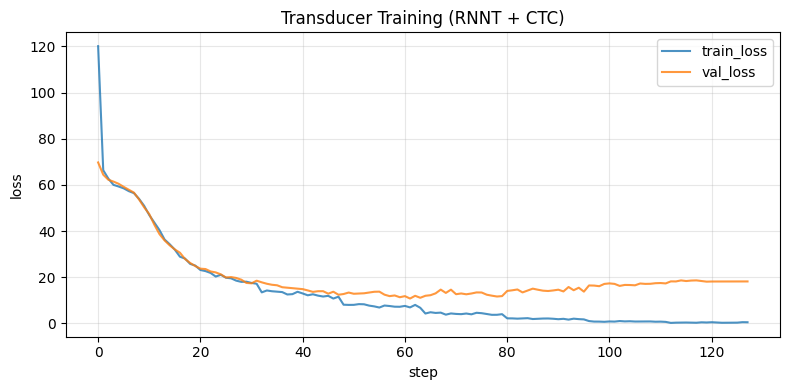

epoch 0 step 15 index (2536,)| rnnt: 1088.1565 | ctc: 31.3551 | total: 771.1160
epoch 0 step 31 index (7428,)| rnnt: 284.4962 | ctc: 21.6633 | total: 205.6463
epoch 0 step 47 index (6278,)| rnnt: 450.1613 | ctc: 23.4924 | total: 322.1606
epoch 0 step 63 index (6725,)| rnnt: 226.0719 | ctc: 20.6413 | total: 164.4427
epoch 0 step 79 index (4166,)| rnnt: 226.6243 | ctc: 18.6357 | total: 164.2277
epoch 0 step 95 index (5367,)| rnnt: 287.3069 | ctc: 17.3499 | total: 206.3198
epoch 0 step 111 index (6015,)| rnnt: 132.6325 | ctc: 25.0323 | total: 100.3525
epoch 0 step 127 index (2898,)| rnnt: 123.2910 | ctc: 27.9588 | total: 94.6914
epoch 0 step 143 index (8045,)| rnnt: 198.0133 | ctc: 26.4282 | total: 146.5378
epoch 0 step 159 index (7892,)| rnnt: 126.9853 | ctc: 23.2862 | total: 95.8756
epoch 0 step 175 index (8008,)| rnnt: 179.9273 | ctc: 29.8756 | total: 134.9118
epoch 0 step 191 index (822,)| rnnt: 83.2948 | ctc: 23.2092 | total: 65.2691
epoch 0 step 207 index (6214,)| rnnt: 185.1512 | c

In [ ]:
# cell for training

epochs = 8
accumulate_steps = 1

# set up OneCycleLR scheduler
steps_per_epoch = math.ceil(len(training_dataloader) / accumulate_steps)  
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,          # lower the peak lr
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    pct_start=0.35,       # longer warmup
    anneal_strategy='cos',
    div_factor=25.0,      # start = max_lr/25
    final_div_factor=100, # end ≈ 1e-6
)

# settings for plotting
_first_plot = True
step_count = 0

fig = plt.figure(figsize=(8,4))
plt.plot()
display(fig, display_id="loss_plot")   
plt.close(fig)  

val_subset_loader = make_val_subset_loader(val_dataset, sample_size=64, batch_size=16, seed=None) 

for e in range(epochs):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    epoch_loss_sum = 0.0
    micro_steps = 0

    current_accum_losses = []        # a list for batch losses within accumulation, will be cleared after each update
    current_accum_batch_sizes = []   # a list for batch sizes within accumulation, will be cleared after each update

    for idx, (padded_encoder_inputs, input_len, padded_decoder_inputs, target_len, data_idx) in enumerate(training_dataloader):
        
        x, x_len_long, y_long, y_len_long = prepare_inputs(
            padded_encoder_inputs, input_len, padded_decoder_inputs, target_len
        )

        logits4d, in_lens_long, y_in_lens, ctc_logits = model(x, x_len_long, y_long, y_len_long) 

        # RNNT loss
        rnnt_loss = criterion(logits4d, y_long.to(torch.int32), in_lens_long.to(torch.int32), y_len_long.to(torch.int32))

        # CTC loss
        log_probs = (ctc_logits.permute(1, 0, 2) / temperature).log_softmax(2)   # (B, T_, V) -> (T_, B, V) 
        ctc_loss = ctc_loss_fn(log_probs, y_long, in_lens_long, y_len_long)

        batch_total_loss = lambda_rnnt * rnnt_loss + lambda_ctc * ctc_loss   # total loss for the batch

        # add loss and batch size for accumulation tracking
        bs = x.size(0) if x is not None else 1   # batch size (in case batch_size > 1 and last batch is smaller)
        train_batch_losses.append(float(batch_total_loss.detach().item()))  
        current_accum_losses.append(float(batch_total_loss.detach().item()) * bs)   
        current_accum_batch_sizes.append(bs)    

        # for gradient accumulation, loss should be averaged over accumulate_steps
        (batch_total_loss / accumulate_steps).backward()

        # do step all the time. Uncomment below to set a rule
        # do_step = ((idx + 1) % accumulate_steps == 0) or (idx + 1 == len(training_dataloader))
        if True: # do_step:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

            # validate every 512 samples
            validate = ((idx + 1) % (512//batch_size) == 0) or (idx + 1 == len(training_dataloader))
            if validate: #and e >= 1:
                model.eval()
                
                val_sum = 0.0
                val_weight = 0

                # calculate average training loss till this validation step
                if sum(current_accum_batch_sizes) > 0:
                    update_loss = sum(current_accum_losses) / sum(current_accum_batch_sizes)
                else:
                    update_loss = float('nan')
                train_accum_losses.append(update_loss) 

                current_accum_losses = []
                current_accum_batch_sizes = []

                with torch.no_grad():
                    for ve, vlen, vy, vylen, vidx in val_subset_loader:
                        ve, vlen, vy, vylen = prepare_inputs(ve, vlen, vy, vylen)
                        v_logits4d, v_in_lens, v_y_in_lens, v_ctc_logits = model(ve, vlen, vy, vylen)

                        v_rnnt_loss = criterion(v_logits4d, vy.to(torch.int32), v_in_lens.to(torch.int32), vylen.to(torch.int32))
                        
                        v_log_probs = (v_ctc_logits.permute(1, 0, 2) / temperature).log_softmax(2)
                        v_ctc_loss = ctc_loss_fn(v_log_probs, vy, v_in_lens, vylen)

                        v_batch_loss = lambda_rnnt * v_rnnt_loss + lambda_ctc * v_ctc_loss

                        v_bs = ve.size(0)       
                        val_sum += float(v_batch_loss.detach().item()) * v_bs   
                        val_weight += v_bs
        
                mean_val_loss = val_sum / max(1, val_weight)
                val_batch_losses.append(mean_val_loss)

                print(f"[VAL @update {step_count}] mean_val_loss: {mean_val_loss:.6f}  (samples={val_weight})")
                
                model.train()

                # ========== plot training and validation loss curves ==========
                fig = plt.figure(figsize=(8,4))
                # print(train_accum_losses, val_batch_losses)
                plt.plot(train_accum_losses, label="train_loss", alpha=0.8)
                if 'val_epoch_losses' in globals() and len(val_epoch_losses) > 0:
                    try:
                        eval_interval_steps  
                        val_x = list(range(0, len(train_accum_losses), eval_interval_steps))[:len(val_epoch_losses)]
                    except NameError:
                        val_x = list(range(len(val_epoch_losses)))
                plt.plot(val_batch_losses, label="val_loss", alpha=0.8) #, marker='o')
                plt.xlabel("step")
                plt.ylabel("loss")
                plt.grid(alpha=0.3)
                plt.legend()
                plt.title("Transducer Training (RNNT + CTC)")
                plt.tight_layout()

                update_display(fig, display_id="loss_plot")  
                plt.close(fig)  
            if (idx+1) % 16 == 0:
                print(f"epoch {e} step {idx} index {data_idx}| rnnt: {float(rnnt_loss):.4f} | ctc: {float(ctc_loss):.4f} | total: {float(batch_total_loss):.4f}")
    
    # save weights only
    torch.save(model.state_dict(), f"model_weights_Transducer_5_epochs_{e}.pth")
        
    # save full model
    torch.save(model, f"model_full_Transducer_5_epochs_{e}.pth")


# save loss lists
with open("train_accum_losses.pkl", "wb") as f:
    pickle.dump(train_accum_losses, f)

with open("val_batch_losses.pkl", "wb") as f:
    pickle.dump(val_batch_losses, f)   

print("模型权重和结构已保存。")     # "Model weights and structure have been saved."

In [ ]:
# calculate model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 51616274
Trainable parameters: 51616274


In [ ]:
# keep Kaggle running
import time

while True:
    print("still running...")
    time.sleep(60)

still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...
still running...


KeyboardInterrupt: 

### Predict

After experimenting various parameter combinations, we achieved the best phoneme accuracy of 21.65% for this model. Post analyses suggest there might be few potential improvements points:  
1. not depend on  but on days

In [ ]:
# load model and evaluate on val set
model_path = "model_full_Transducer_5_epochs_6.pth"
model = torch.load(model_path, map_location=DEVICE, weights_only=False)  
model.eval()

decode_list = []
target_list = []

for v_data, v_data_len, v_label, vlabel_len, v_idx, v_sent in val_dataset:
    decode_list.append(rnn_decode(model, val_dataset, v_idx, max_symbols_per_step=10))
    target_list.append(v_label.tolist())
    if v_idx % 100 == 0:
        print(f'val {v_idx} done')

rper_day = calculate_aggregate_error_rate(decode_list, target_list)
print(f'rPER: {rper_day[0]*100:.2f}%')

In [ ]:
# write decoded validation data to a text file
with open('val_dataset', 'w', encoding='utf-8') as f:
    for i in range(len(val_dataset)):
        f.write(f"{phoneme_id_to_phoneme(decode_list[i])}^{val_dataset[i][-1]}\n")
        f.write(f"{phoneme_id_to_phoneme(target_list[i])}^{val_dataset[i][-1]}\n")
        if i % 100 == 0:
            print(f"Written {i} lines...")

In [ ]:
# write decoded test data to a text file
with open('test_dataset', 'w', encoding='utf-8') as f:
    for i in range(len(test_dataset)):
        f.write(f"{phoneme_id_to_phoneme(decode_list_test[i])}\n")
        if i % 100 == 0:
            print(f"Written {i} lines...")